In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plot
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
from sklearn.model_selection import cross_val_score
import seaborn as sns 
from sklearn import tree

In [2]:
df = pd.read_csv('drug200.csv')

In [3]:
LabelEncoder = LabelEncoder()
df['Sex'] = LabelEncoder.fit_transform(df['Sex'].values)
df['BP'] = LabelEncoder.fit_transform(df['BP'].values)
df['Cholesterol'] = LabelEncoder.fit_transform(df['Cholesterol'].values)

In [4]:
x = df.drop(['Drug'], axis=1)
y = df['Drug']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [6]:
tree_m = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_m.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [7]:
predict = tree_m.predict(x_test)

In [8]:
print('accurancy score: ', accuracy_score(y_test, predict))

accurancy score:  0.88


confusion_matrix: 
 [[ 6  0  0  0  0]
 [ 0  3  0  0  0]
 [ 0  0  0  6  0]
 [ 0  0  0 15  0]
 [ 0  0  0  0 20]]


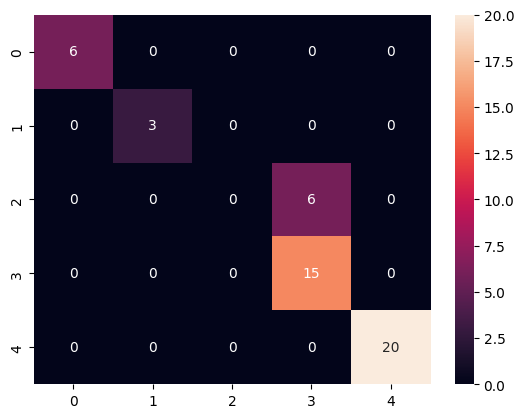

In [9]:
print('confusion_matrix: \n', confusion_matrix(y_test, predict))
sns.heatmap(confusion_matrix(y_test, predict), annot=True)
plot.show()

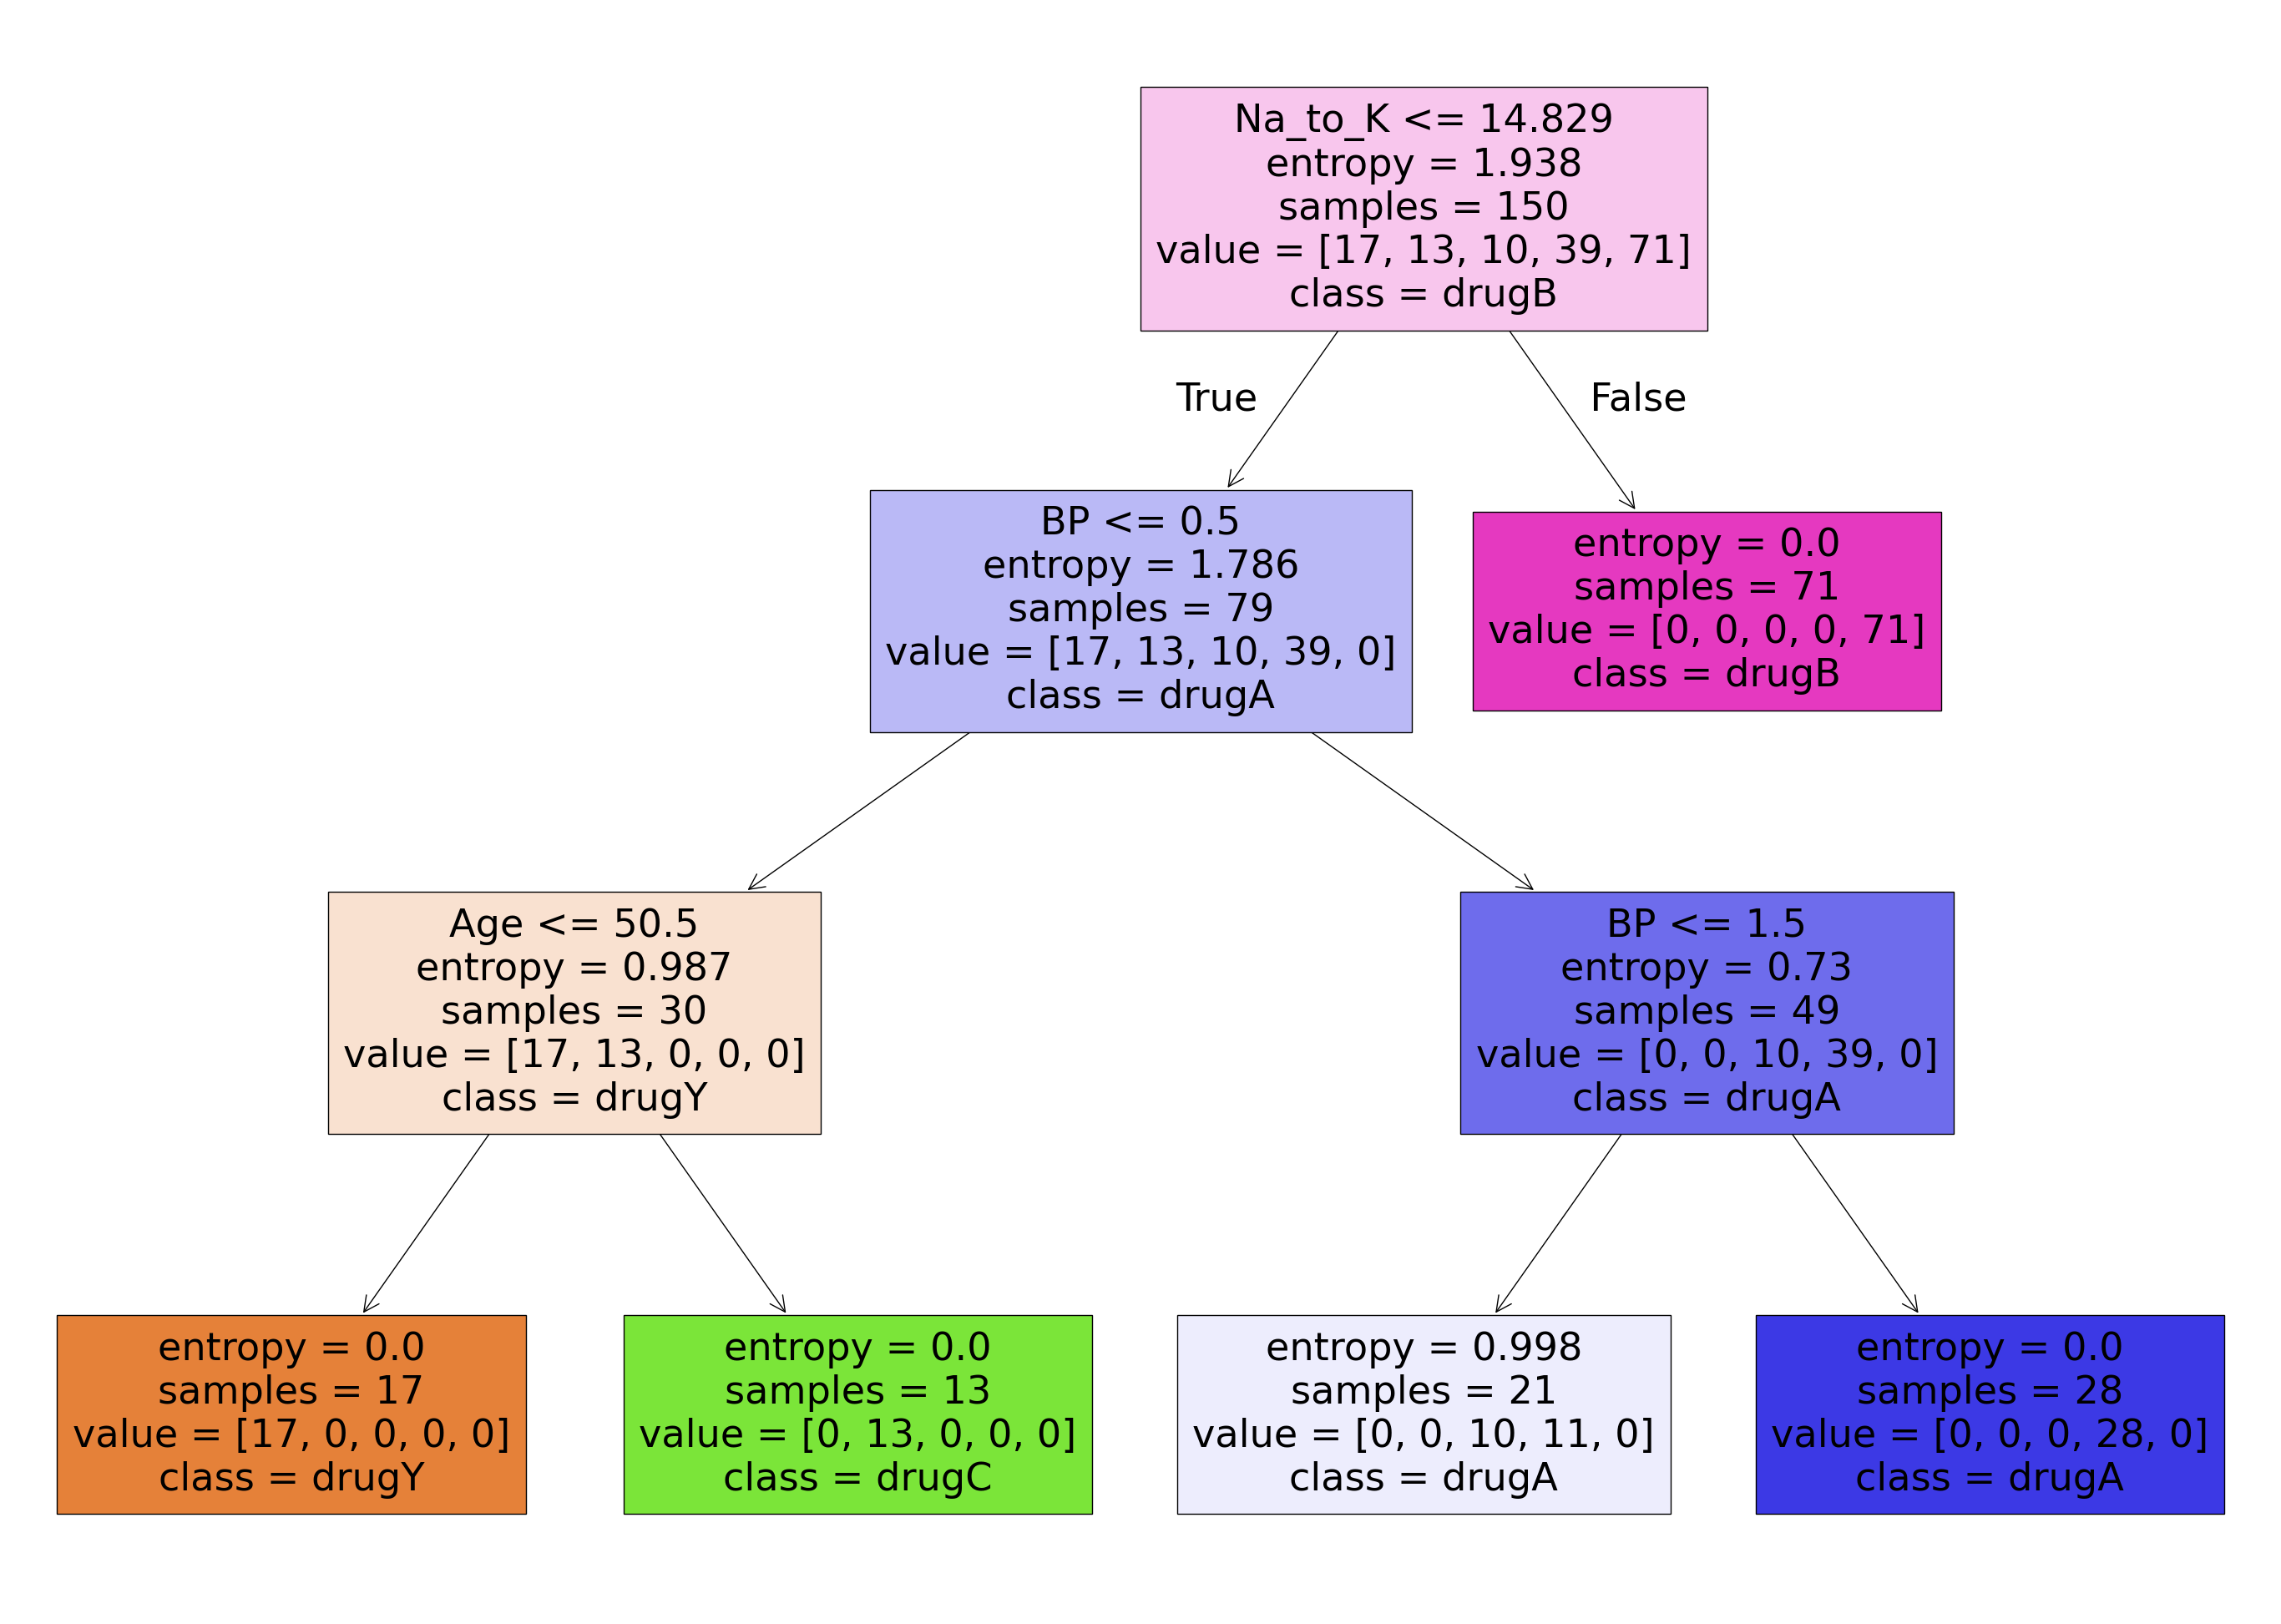

In [10]:
cols = df.drop(['Drug'], axis=1).columns
classes = df['Drug'].unique()

plot.figure(figsize=(35, 25))
tree.plot_tree(tree_m, feature_names=cols, class_names=classes, filled=True)
plot.show()

decision tree accuracy:  0.82


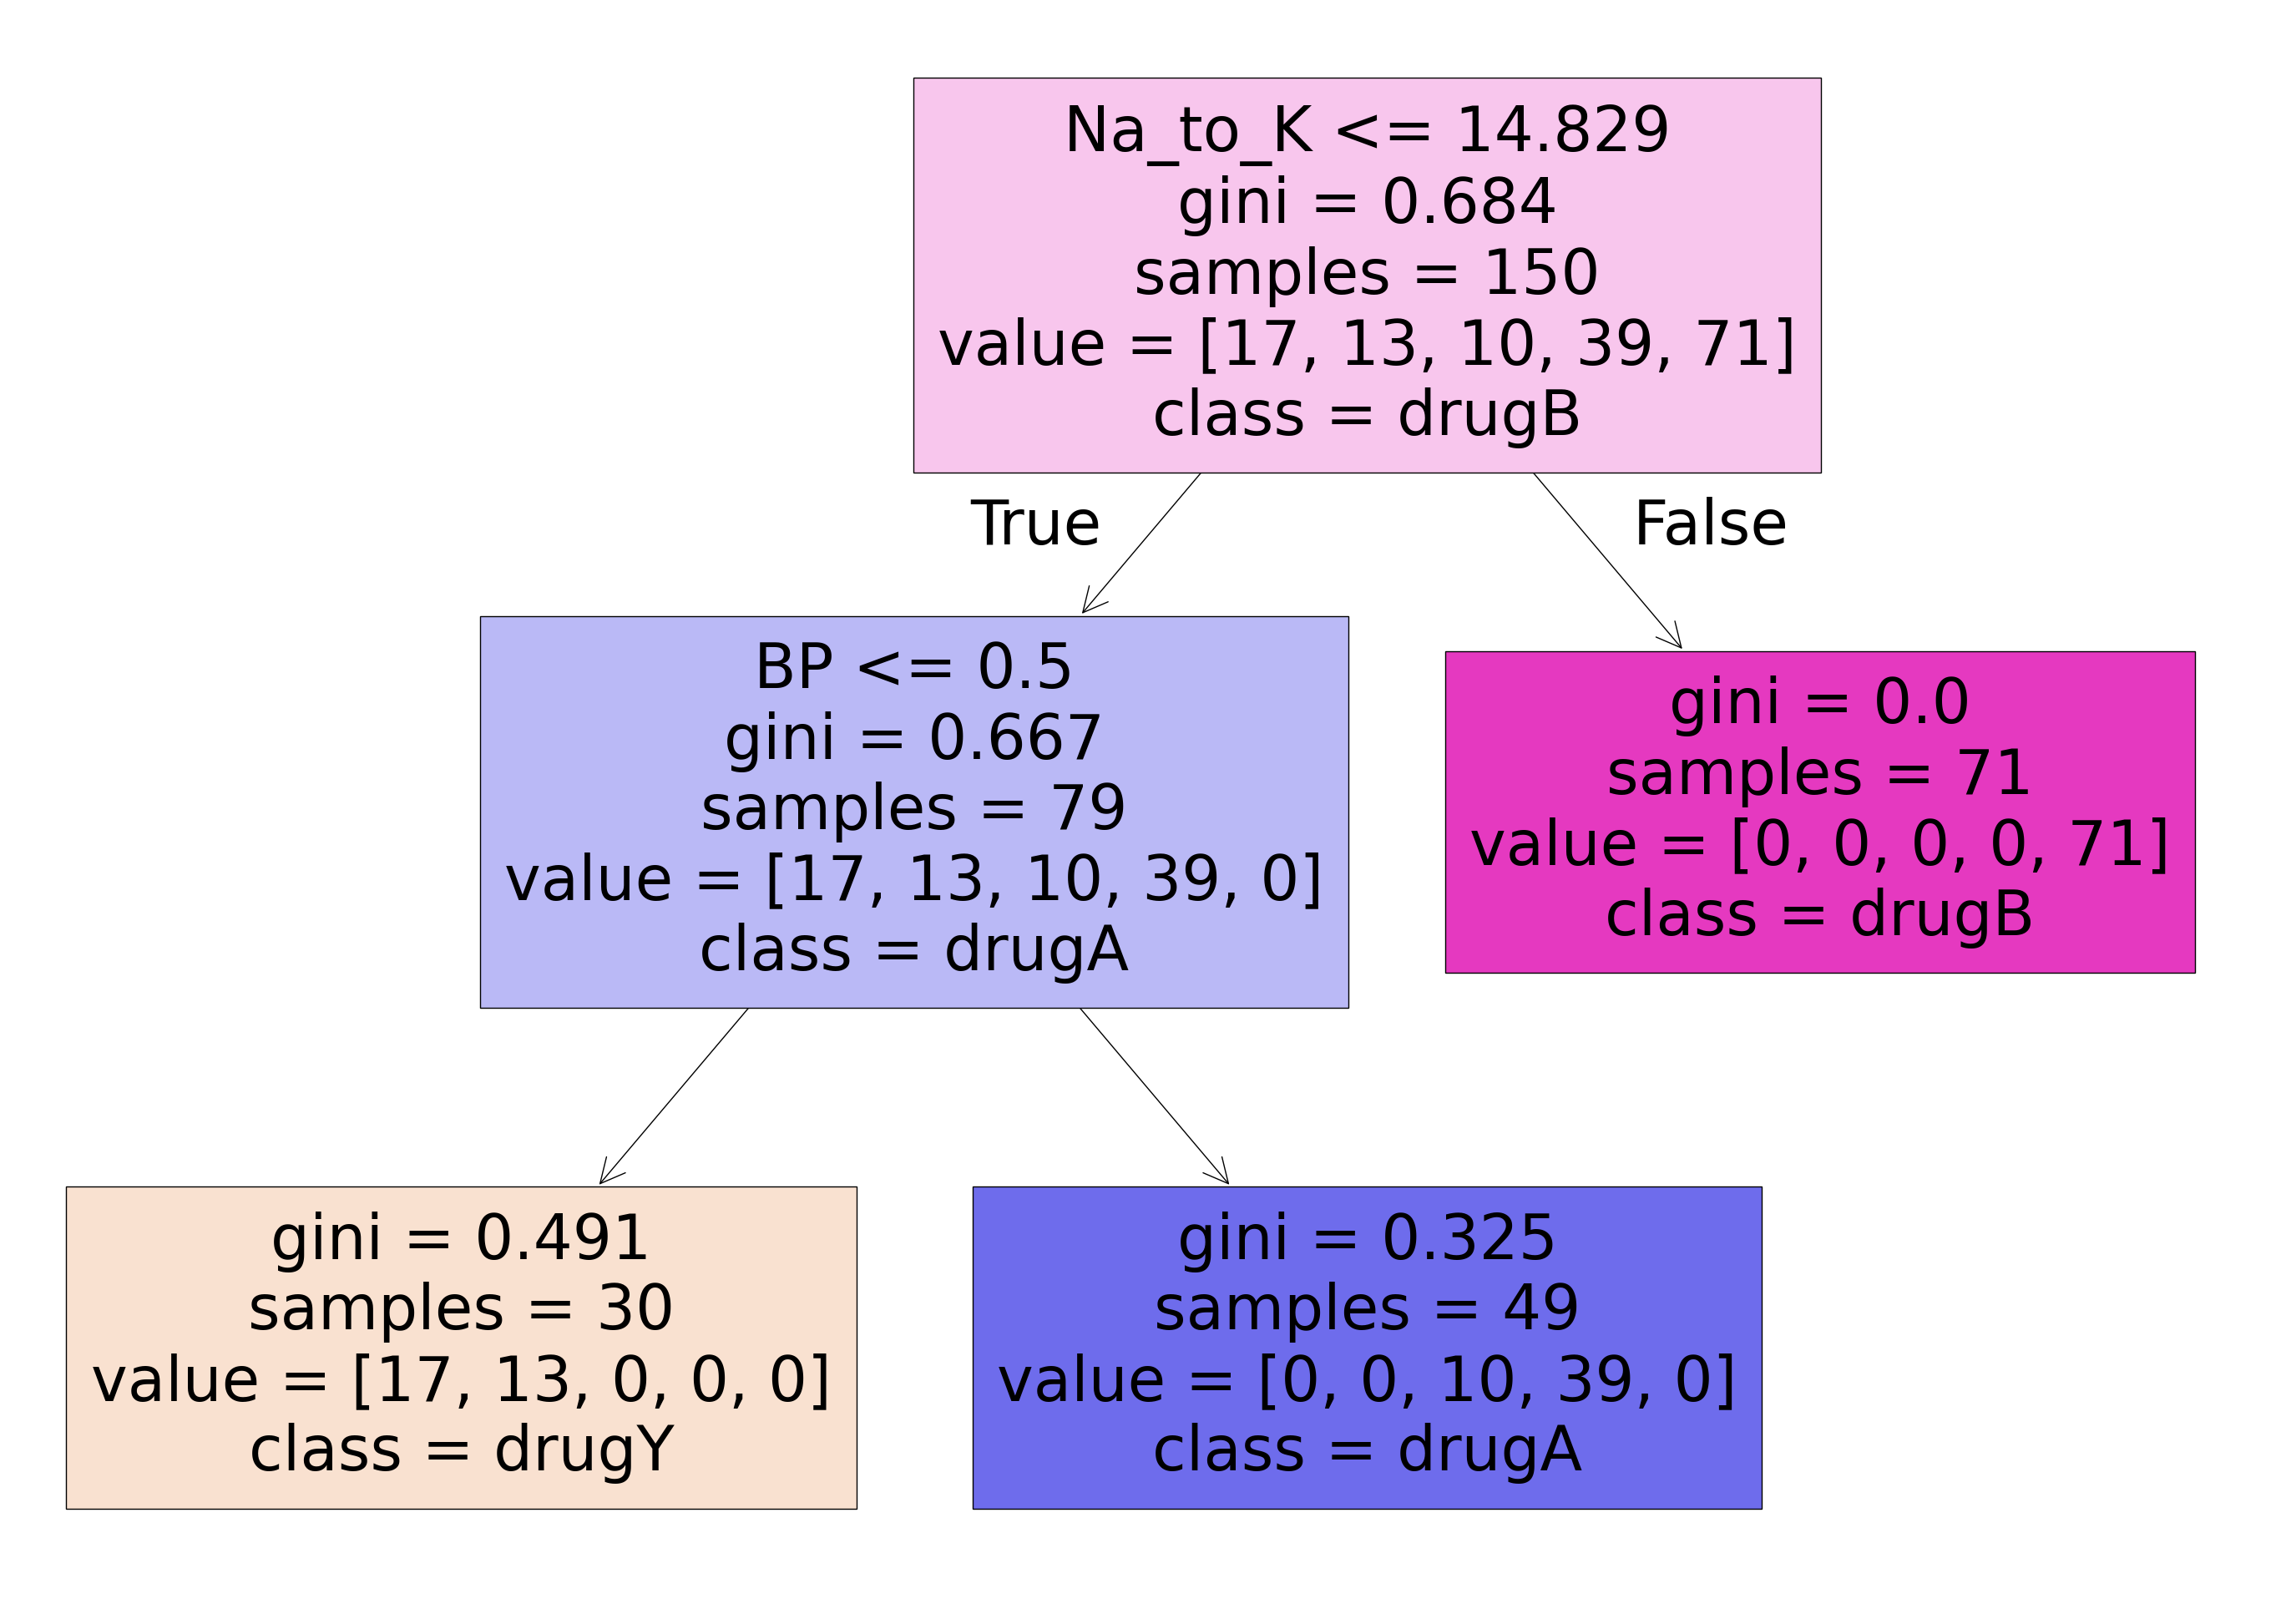

In [11]:
tree_m = DecisionTreeClassifier(min_impurity_decrease=0.1, random_state=42)
tree_m.fit(x_train, y_train)
y_pred = tree_m.predict(x_test)
print('decision tree accuracy: ', accuracy_score(y_test, y_pred))

plot.figure(figsize=(35, 25))
tree.plot_tree(tree_m, feature_names=cols, class_names=classes, filled=True)
plot.show()

decision tree accuracy:  0.82


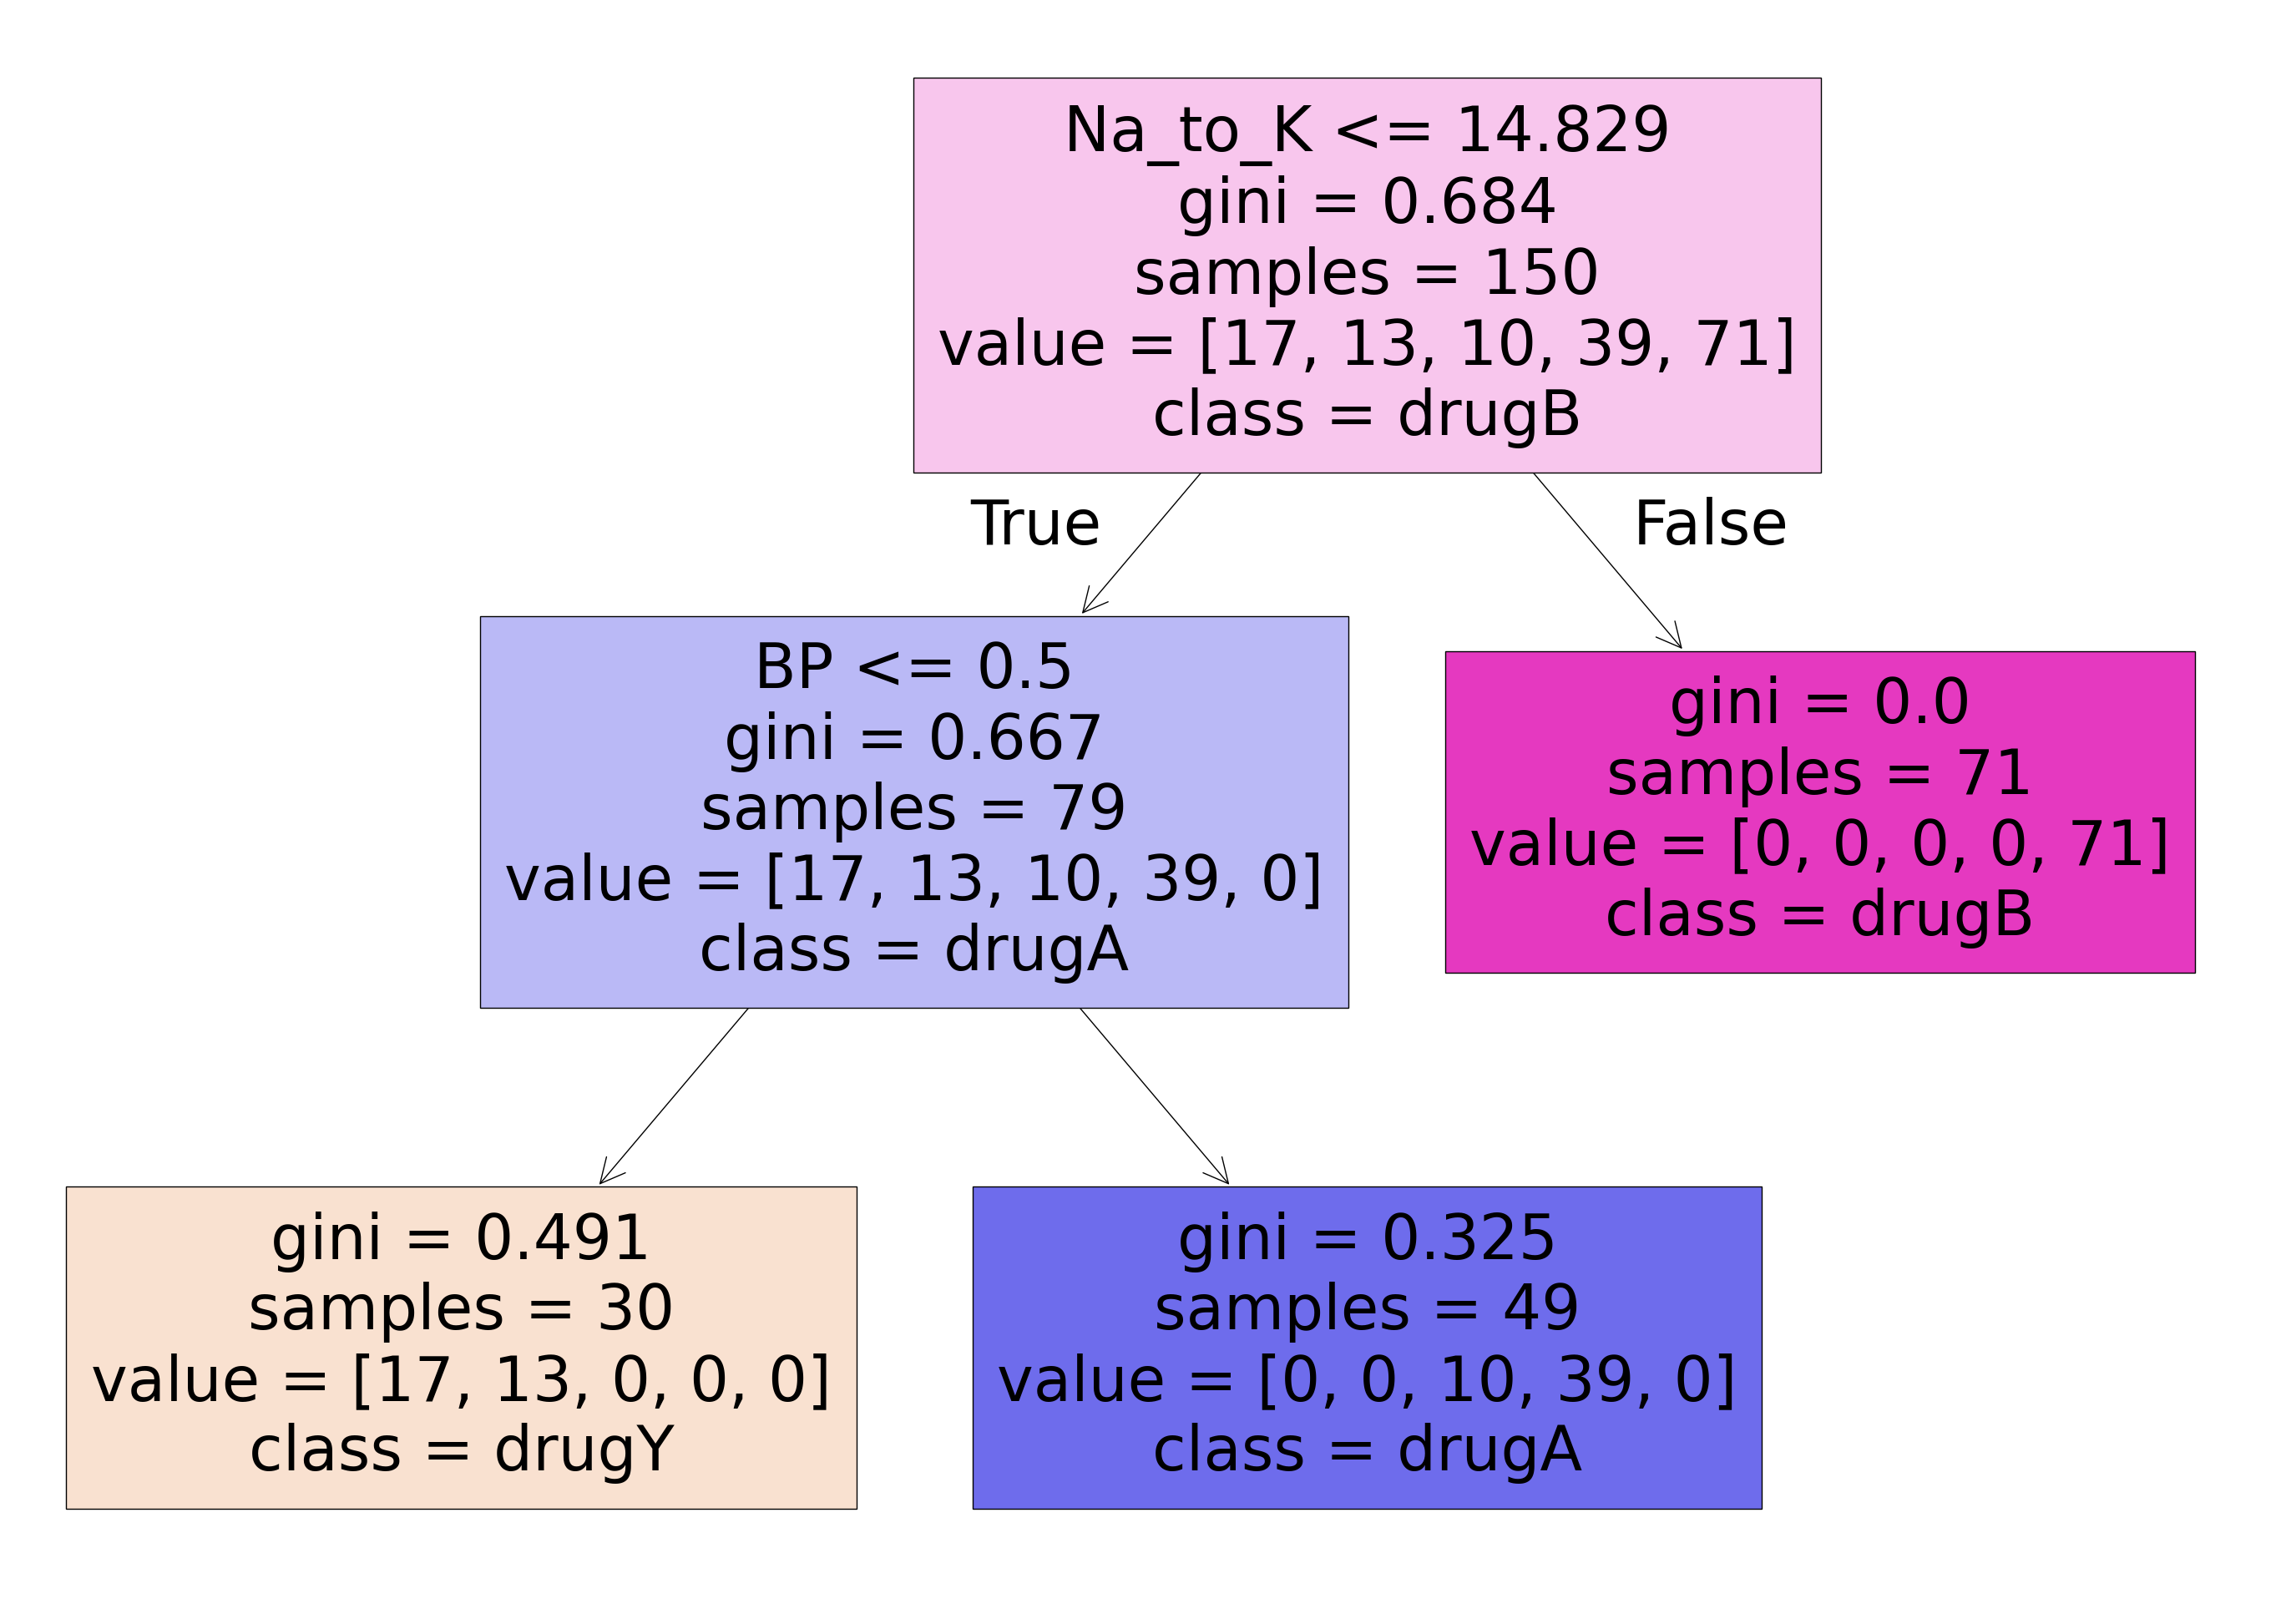

In [12]:
tree_m = DecisionTreeClassifier(min_samples_split=5, max_depth=2)
tree_m.fit(x_train, y_train)
y_pred = tree_m.predict(x_test)
print('decision tree accuracy: ', accuracy_score(y_test, y_pred))

plot.figure(figsize=(35, 25))
tree.plot_tree(tree_m, feature_names=cols, class_names=classes, filled=True)
plot.show()

decision tree accuracy:  1.0


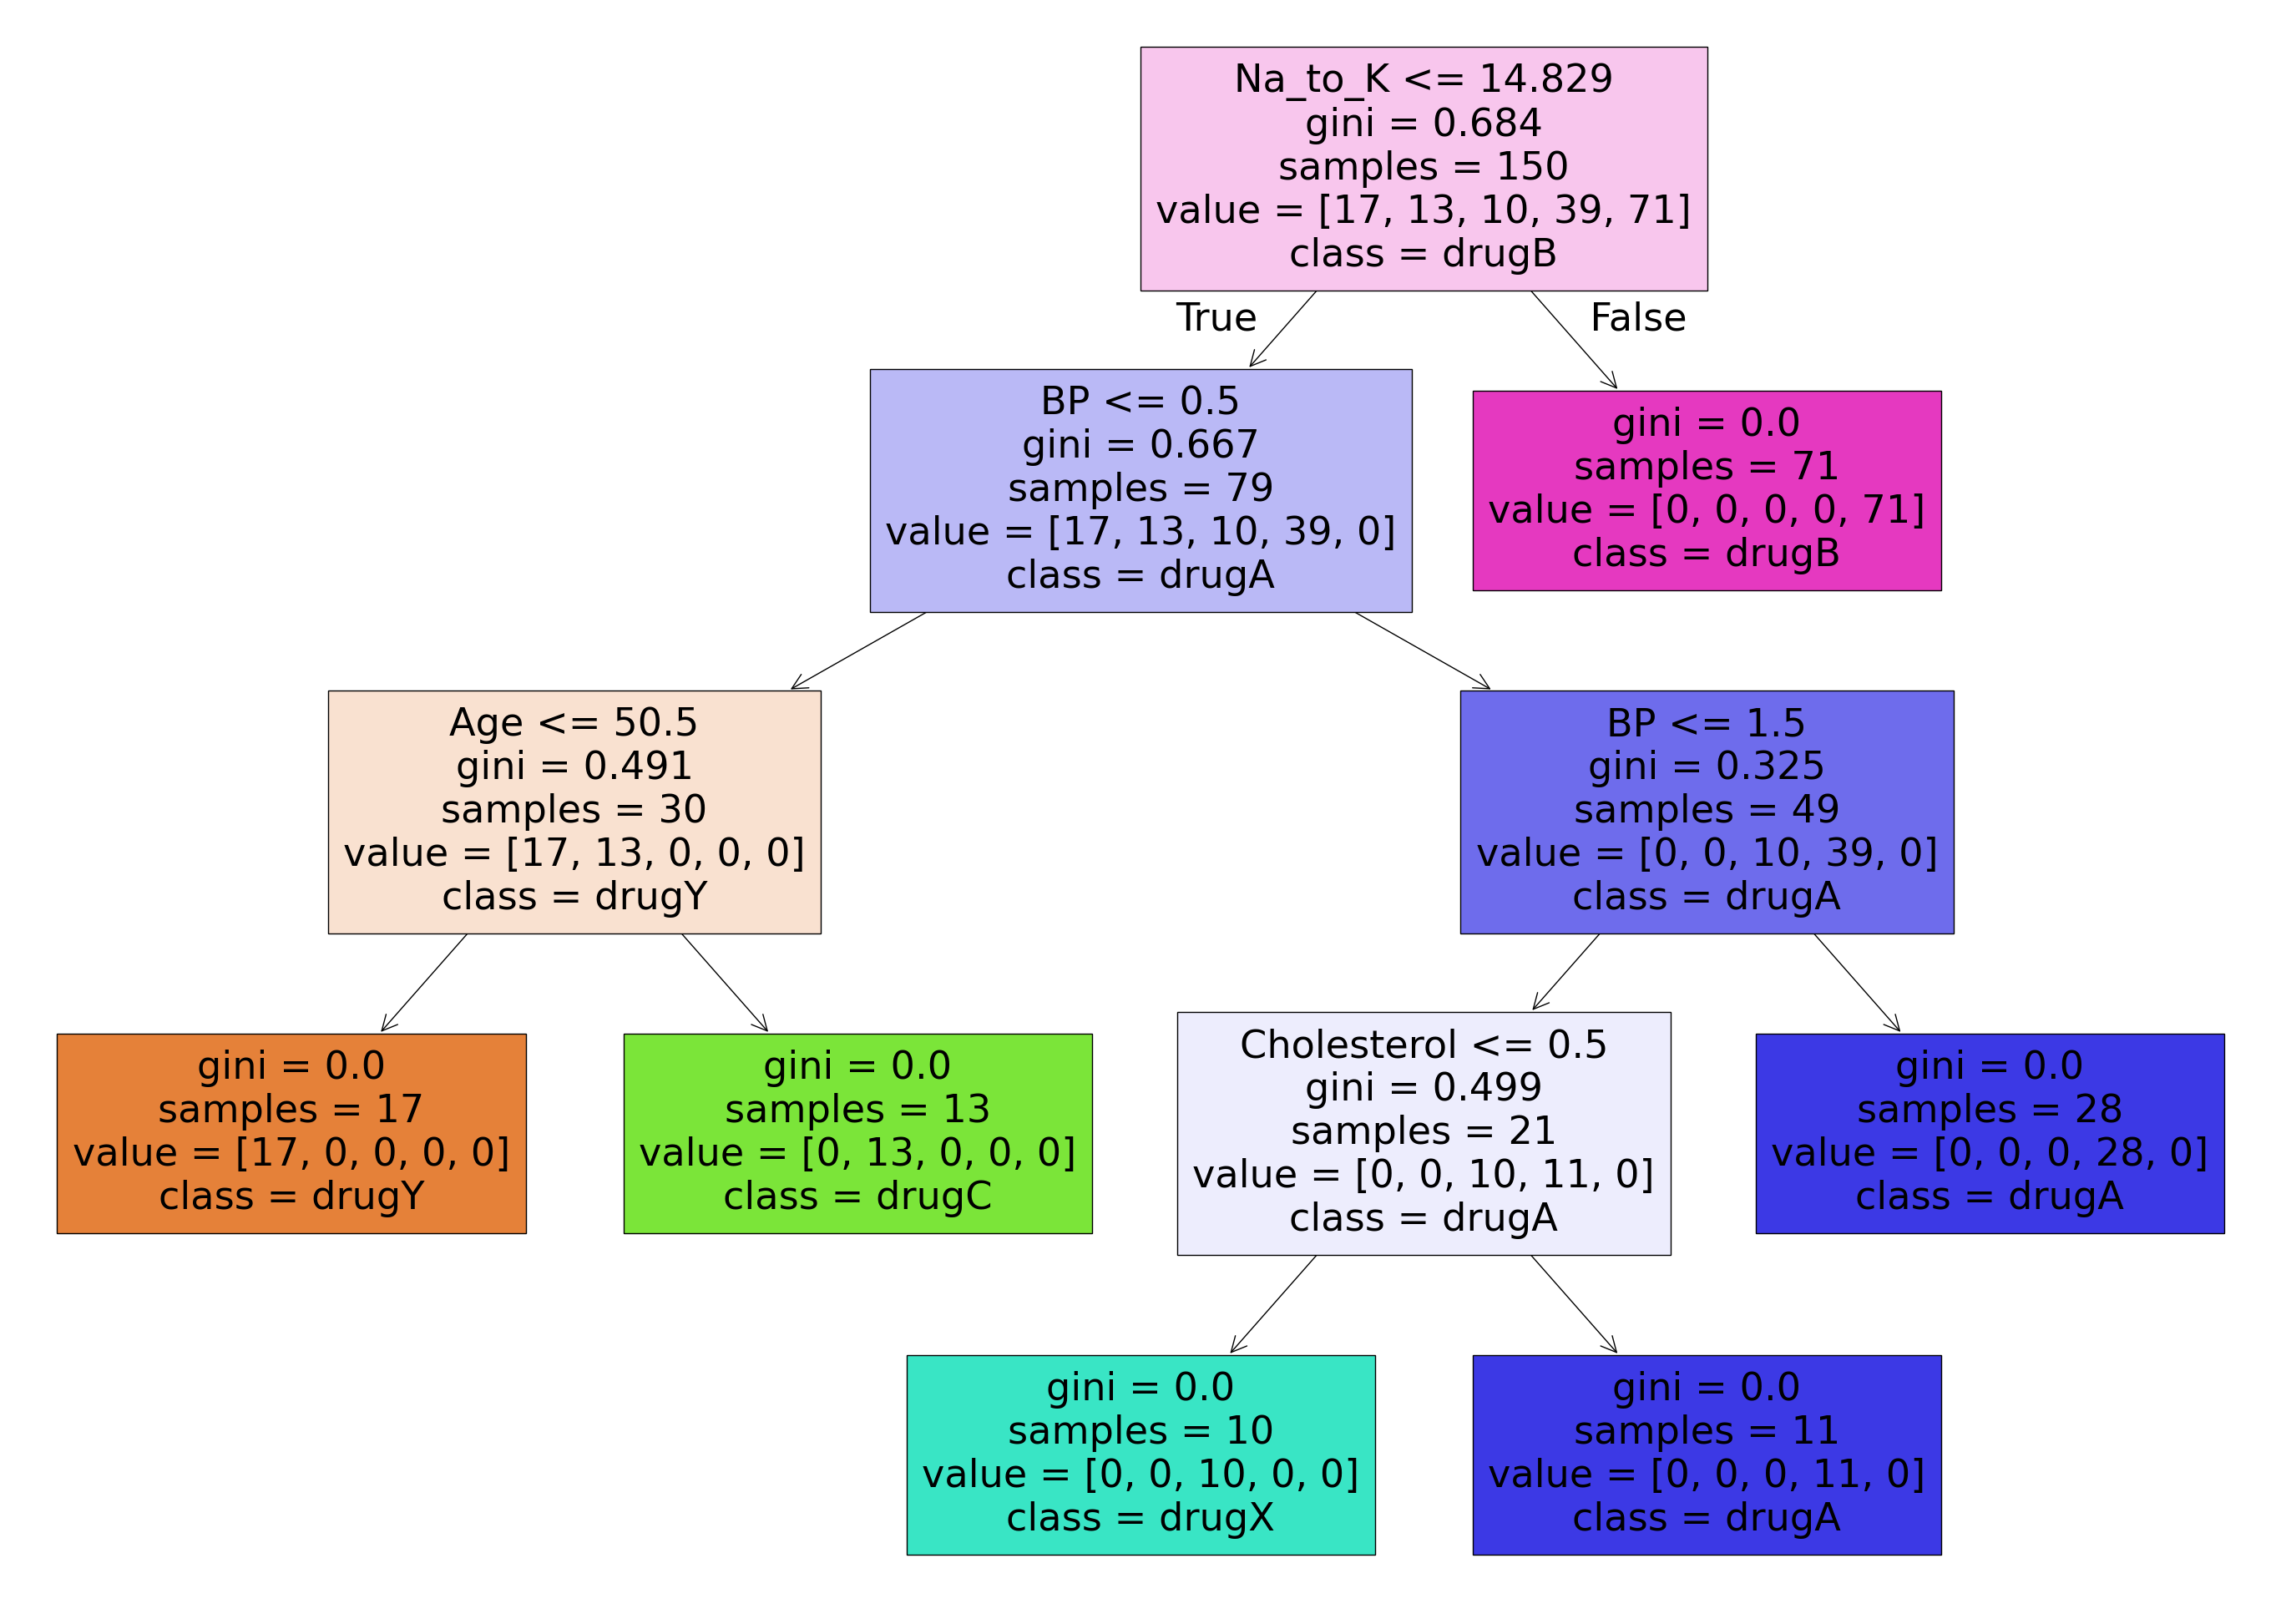

In [13]:
tree_m = DecisionTreeClassifier(min_impurity_decrease=0.0, random_state=42)
tree_m.fit(x_train, y_train)
y_pred = tree_m.predict(x_test)
print('decision tree accuracy: ', accuracy_score(y_test, y_pred))

plot.figure(figsize=(35, 25))
tree.plot_tree(tree_m, feature_names=cols, class_names=classes, filled=True)
plot.show()

In [14]:
rf = RandomForestClassifier(n_estimators=20)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print('random forest accuracy: ', accuracy_score(y_test, y_pred))

random forest accuracy:  0.98
